In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as sp_stats

import sys
from pathlib import Path
sys.path.insert(0, str(Path("../../scripts").resolve()))
import graph_export

In [3]:
# Toggle x-axis - truncated: True = types, False = tokens
USE_DISTINCT_WORDS = False
# Toggle y-axis metric – original: True = types, False = tokens
Y_USE_DISTINCT_WORDS = True


## Zero-crossing breakpoint detection

For each coverage level $c$, the relationship between corpus size $x$ and truncated size $y_c$ is modeled in log-log space:

$$\log_{10} y_c = \beta \cdot \log_{10} x + \alpha$$

Sweep candidate breakpoints $b$ left-to-right through $\log_{10} x$, fitting a linear regression on the **right** segment ($\log_{10} x > b$). The right-side slope $\beta_R(b)$ starts positive (small corpora gain types proportionally) and decreases toward zero for large corpora.

The first sign change $\beta_R(b_i) \cdot \beta_R(b_{i+1}) < 0$ triggers a binary search to locate $b^*$ where $\beta_R \approx 0$. The breakpoint $10^{b^*}$ marks the corpus size above which adding more tokens no longer increases the truncated vocabulary.

In [4]:

stats_sw = pd.read_csv("../../../results/1_process/3_truncate/statistics.csv")
x_col_sw = "distinct_words" if USE_DISTINCT_WORDS else "total_frequency"
y_sfx_sw = "_types" if Y_USE_DISTINCT_WORDS else "_tokens"
cov_cols_sw = [c for c in stats_sw.columns if c.startswith("cov_") and c.endswith(y_sfx_sw)]

def parse_coverage_levels(cov_cols, y_sfx):
    """Parse coverage percentage from column names (e.g. cov_91_5_types → 91.5)."""
    levels = []
    for c in cov_cols:
        inner = c[len("cov_"):-len(y_sfx)]
        parts = inner.split("_")
        if len(parts) == 2:
            levels.append(float(f"{parts[0]}.{parts[1]}"))
        else:
            levels.append(float(parts[0]))
    return levels

def right_slope_at(log_x, log_y, bp_log):
    """Compute right-side slope for a given breakpoint in log space."""
    right = log_x > bp_log
    if right.sum() < 5:
        return np.nan
    sl, _, _, _, _ = sp_stats.linregress(log_x[right], log_y[right])
    return sl

def binary_search_breakpoint(log_x, log_y, lo, hi, prev_slope):
    """Binary search between two candidates to find the zero-slope breakpoint."""
    for _ in range(50):
        mid = (lo + hi) / 2
        mid_slope = right_slope_at(log_x, log_y, mid)
        if np.isnan(mid_slope):
            break
        if abs(mid_slope) < 1e-6:
            break
        if mid_slope * prev_slope > 0:
            lo = mid
        else:
            hi = mid
            
    bp_final = (lo + hi) / 2
    final_slope = right_slope_at(log_x, log_y, bp_final)
    left_mask = log_x <= bp_final
    right_mask = log_x > bp_final
    sl_l, _, _, _, _ = sp_stats.linregress(log_x[left_mask], log_y[left_mask])
    return {
        "bp_log": bp_final,
        "bp_val": 10 ** bp_final,
        "right_slope": final_slope,
        "left_slope": sl_l,
        "n_right": int(right_mask.sum()),
        "n_left": int(left_mask.sum()),
    }

def find_zero_crossing_bp(log_x, log_y, min_seg):
    """Sweep left-to-right, find first sign change in right slope, binary search for zero."""
    n = len(log_x)
    candidates = log_x[min_seg : n - min_seg]
    if len(candidates) < 2:
        return None

    prev_slope = right_slope_at(log_x, log_y, candidates[0])
    for i in range(1, len(candidates)):
        curr_slope = right_slope_at(log_x, log_y, candidates[i])
        if np.isnan(prev_slope) or np.isnan(curr_slope):
            prev_slope = curr_slope
            continue
        if prev_slope * curr_slope < 0:
            return binary_search_breakpoint(log_x, log_y, candidates[i - 1], candidates[i], prev_slope)
        prev_slope = curr_slope
    return None

def sweep_coverages(stats, x_col, cov_cols, cov_levels, min_seg):
    """Run zero-crossing breakpoint analysis for each coverage level."""
    results = []
    for cov_col, cov_level in zip(cov_cols, cov_levels):
        mask = (stats[x_col] > 0) & (stats[cov_col] > 0)
        if mask.sum() < 2 * min_seg + 1:
            results.append((cov_level, np.nan, np.nan, np.nan, np.nan))
            continue

        log_x = np.log10(stats.loc[mask, x_col].values)
        log_y = np.log10(stats.loc[mask, cov_col].values)
        order = np.argsort(log_x)
        log_x, log_y = log_x[order], log_y[order]

        res = find_zero_crossing_bp(log_x, log_y, min_seg)
        if res is not None:
            results.append((cov_level, res["bp_val"], res["right_slope"], res["n_right"], res["left_slope"]))
        else:
            results.append((cov_level, np.nan, np.nan, np.nan, np.nan))
    return pd.DataFrame(results, columns=["coverage", "breakpoint", "right_slope", "n_right", "left_slope"])

def print_best_coverage(res_df):
    """Print summary of zero-crossing breakpoint analysis."""
    res_valid = res_df.dropna()
    print(f"Coverages with a zero-crossing breakpoint: {len(res_valid)} / {len(res_df)}")
    if len(res_valid) > 0:
        best_row = res_valid.loc[res_valid["n_right"].idxmax()]
        print(f"Best coverage (most languages right of zero-slope BP): {best_row.coverage}%")
    return res_valid



cov_levels_sw = parse_coverage_levels(cov_cols_sw, y_sfx_sw)

min_segment_size = 15
res_df = sweep_coverages(stats_sw, x_col_sw, cov_cols_sw, cov_levels_sw, min_segment_size)
res_valid = print_best_coverage(res_df)

Coverages with a zero-crossing breakpoint: 39 / 40
Best coverage (most languages right of zero-slope BP): 84.0%


## Elbow detection on zero-crossing breakpoints

The previous step yields a breakpoint $b^*(c)$ for each coverage level $c$. To find the optimal coverage, fit a **two-piece linear model** on the curve $c \mapsto \log_{10} b^*(c)$:

$$\log_{10} b^*(c) = \begin{cases} a_L \, c + d_L & c \le c^* \\ a_R \, c + d_R & c > c^* \end{cases}$$

For every candidate split $c^*$, the total sum of squared errors:

$$\text{SSE}(c^*) = \sum_{c \le c^*} \bigl(\log_{10} b^*(c) - \hat{y}_L(c)\bigr)^2 + \sum_{c > c^*} \bigl(\log_{10} b^*(c) - \hat{y}_R(c)\bigr)^2$$

The elbow is the $c^*$ minimizing $\text{SSE}(c^*)$. Below this coverage the breakpoint drops sharply (loose cutoff, many types retained); above it the breakpoint plateaus (tight cutoff, diminishing returns).

Best elbow candidates (by total SSE):
 splitCoverage  breakpoint  n_right  totalSSE  leftSlope  rightSlope  slopeChange
          94.0     2929563      177  1.324470  -0.020056    0.222934     0.242990
          93.5     2821080      177  1.324897  -0.020732    0.207465     0.228197
          92.5     2197658      185  1.335648  -0.022112    0.182357     0.204469
          93.0     2807777      178  1.344485  -0.021399    0.191932     0.213331
          94.5     3340115      174  1.358371  -0.019247    0.238155     0.257402
          92.0     2093998      186  1.363999  -0.022451    0.172853     0.195305
          91.5     2079531      187  1.409165  -0.022706    0.163060     0.185766
          91.0     2079531      187  1.467606  -0.022937    0.153327     0.176264
          95.0     4620215      166  1.471761  -0.018070    0.256256     0.274326
          95.5     4620215      166  1.530425  -0.016990    0.291570     0.308560

Best split (elbow): 94.0%

Values at selected coverages:
  

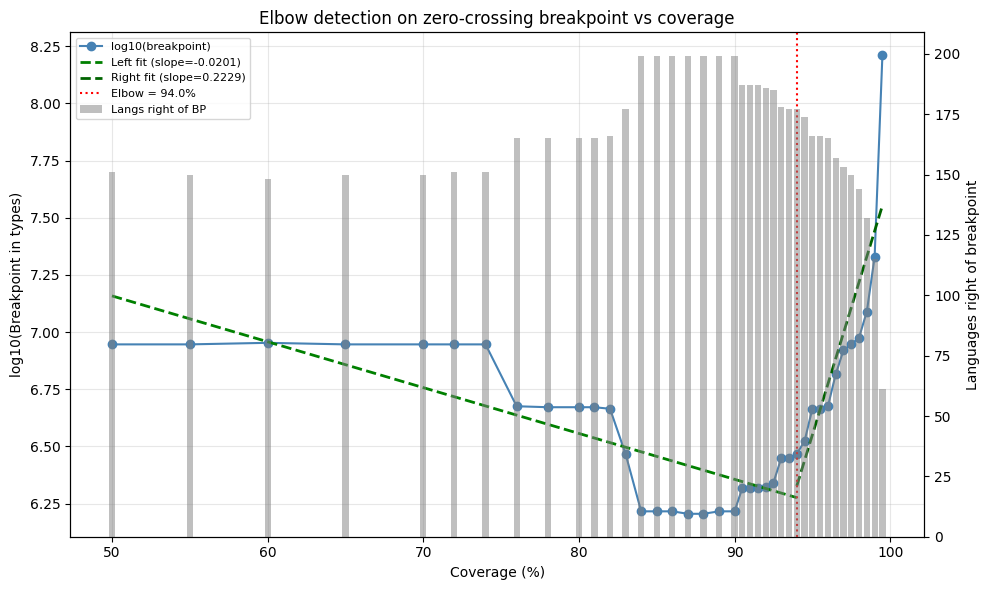

In [5]:
elbow_cov = res_valid["coverage"].values
elbow_log_bp = np.log10(res_valid["breakpoint"].values)
elbow_bp = res_valid["breakpoint"].values
elbow_n_right = res_valid["n_right"].values

def fit_line(x_part, y_part):
    A = np.vstack([x_part, np.ones_like(x_part)]).T
    coeffs, _, _, _ = np.linalg.lstsq(A, y_part, rcond=None)
    slope, intercept = coeffs
    y_pred = slope * x_part + intercept
    sse = np.sum((y_part - y_pred) ** 2)
    return slope, intercept, y_pred, sse

elbow_results = []
for i in range(2, len(elbow_cov) - 2):
    x_left = elbow_cov[:i+1]
    y_left = elbow_log_bp[:i+1]
    x_right = elbow_cov[i:]
    y_right = elbow_log_bp[i:]

    slope_left, intercept_left, yhat_left, sse_left = fit_line(x_left, y_left)
    slope_right, intercept_right, yhat_right, sse_right = fit_line(x_right, y_right)

    elbow_results.append({
        "splitCoverage": elbow_cov[i],
        "breakpoint": int(elbow_bp[i]),
        "n_right": int(elbow_n_right[i]),
        "totalSSE": sse_left + sse_right,
        "leftSlope": slope_left,
        "rightSlope": slope_right,
        "slopeChange": slope_right - slope_left,
    })

elbow_res = pd.DataFrame(elbow_results).sort_values("totalSSE").reset_index(drop=True)

print("Best elbow candidates (by total SSE):")
print(elbow_res.head(10).to_string(index=False))

best_split = elbow_res.loc[0, "splitCoverage"]
print(f"\nBest split (elbow): {best_split:.1f}%")

# Values at specific coverage levels
print("\nValues at selected coverages:")
for cov in [90, 94, 98]:
    row = res_valid.loc[res_valid["coverage"] == cov]
    if len(row) == 1:
        r = row.iloc[0]
        print(f"  {cov}%: breakpoint={int(r.breakpoint):,}, n_right={int(r.n_right)}, right_slope={r.right_slope:.4f}")
    else:
        print(f"  {cov}%: not found in results")

# ── Plot ──
best_i = np.where(elbow_cov == best_split)[0][0]

sl_l, ic_l, yhat_l, _ = fit_line(elbow_cov[:best_i+1], elbow_log_bp[:best_i+1])
sl_r, ic_r, yhat_r, _ = fit_line(elbow_cov[best_i:], elbow_log_bp[best_i:])

fig, ax = plt.subplots(figsize=(10, 6))

# Bar graph for number of languages right of BP (right y-axis)
ax2 = ax.twinx()
ax2.bar(elbow_cov, elbow_n_right, width=0.4, color="gray", alpha=0.5, label="Langs right of BP", zorder=1)
ax2.set_ylabel("Languages right of breakpoint")

ax.plot(elbow_cov, elbow_log_bp, "o-", color="steelblue", label="log10(breakpoint)", zorder=5)
ax.plot(elbow_cov[:best_i+1], yhat_l, "--", color="green", linewidth=2, label=f"Left fit (slope={sl_l:.4f})", zorder=5)
ax.plot(elbow_cov[best_i:], yhat_r, "--", color="darkgreen", linewidth=2, label=f"Right fit (slope={sl_r:.4f})", zorder=5)
ax.axvline(best_split, linestyle=":", color="red", linewidth=1.5, label=f"Elbow = {best_split:.1f}%", zorder=5)
ax.set_xlabel("Coverage (%)")
ax.set_ylabel("log10(Breakpoint in types)" if Y_USE_DISTINCT_WORDS else "log10(Breakpoint in tokens)")
ax.set_title("Elbow detection on zero-crossing breakpoint vs coverage")

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

ax.grid(True, alpha=0.3)
plt.tight_layout()
graph_export.save("elbow", fig)
plt.show()

## Cutoff comparison at two coverage levels

Comparing three truncation strategies in two subplots:
- **Top**: 98% coverage (a loose cutoff for reference)
- **Bottom**: the optimal coverage $c^*$ from the elbow analysis

The vertical breakpoint line is the zero-crossing breakpoint at $c^*$ from the elbow result.

| Strategy | Rule |
|---|---|
| **Coverage** | Keep the top-frequency words covering $c\%$ of all tokens |
| **Frequency $\ge 100$** | Keep words with raw frequency $\ge 100$ |
| **Top 5 % by rank** | Keep the top 5 % of the vocabulary by frequency rank |

Both axes use the same log scale with equal aspect ratio so the diagonal $y = x$ appears at 45°.

In [6]:
# Best elbow result → coverage B and breakpoint
best_elbow = elbow_res.iloc[0]
COVERAGE_A = 98.0
COVERAGE_B = best_elbow["splitCoverage"]
BREAKPOINT = int(best_elbow["breakpoint"])

Graph A: 98.0% coverage
Graph B: 94.0% coverage (best elbow)
Breakpoint: 2,929,563


graph_export: saved original_vs_truncated.pdf


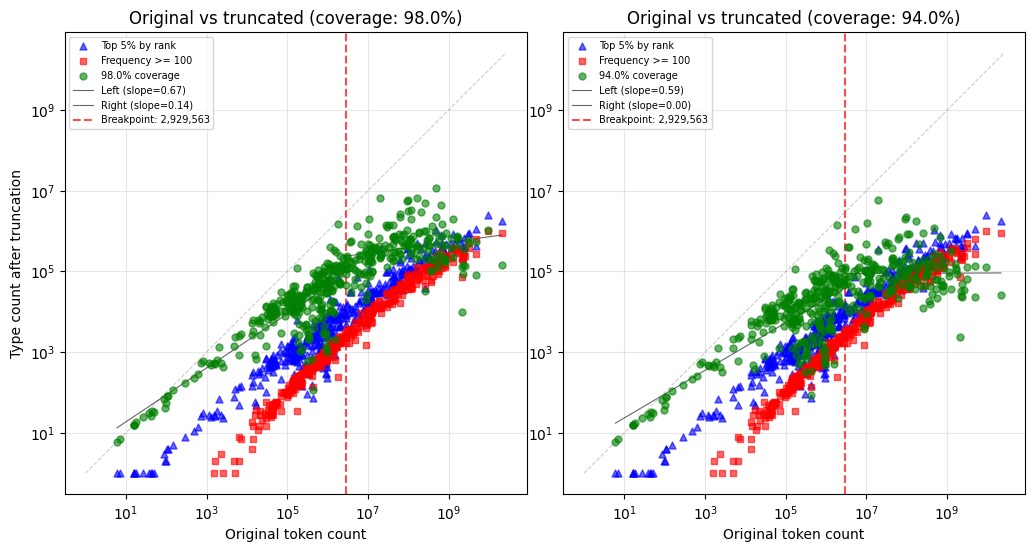


Correlations for 98.0% coverage:
  98.0% coverage      : r = 0.8699
  Frequency >= 100    : r = 0.9879 (skipped 26 with 0)
  Top 5% by rank      : r = 0.9693

Correlations for 94.0% coverage:
  94.0% coverage      : r = 0.7725
  Frequency >= 100    : r = 0.9879 (skipped 26 with 0)
  Top 5% by rank      : r = 0.9693


In [7]:
print(f"Graph A: {COVERAGE_A}% coverage")
print(f"Graph B: {COVERAGE_B}% coverage (best elbow)")
print(f"Breakpoint: {BREAKPOINT:,}")

stats_opt = pd.read_csv("../../../results/1_process/3_truncate/statistics.csv")
x_col = "distinct_words" if USE_DISTINCT_WORDS else "total_frequency"
y_sfx = "_types" if Y_USE_DISTINCT_WORDS else "_tokens"


def coverage_col_name(cov_level, suffix):
    """Build column name from coverage level (e.g. 91.5 → 'cov_91_5_types')."""
    parts = str(cov_level).split(".")
    mid = f"{parts[0]}_{parts[1]}" if len(parts) == 2 and parts[1] != "0" else parts[0]
    return f"cov_{mid}{suffix}"


def build_metrics(cov_level, suffix):
    """Define the three truncation strategies to compare."""
    return [
        (coverage_col_name(cov_level, suffix), f"{cov_level}% coverage", "green",     "o"),
        (f"freq100{suffix}",                   "Frequency >= 100",       "red",       "s"),
        (f"rank5pct{suffix}",                  "Top 5% by rank",         "blue",      "^"),
    ]


def plot_cutoff_comparison(ax, stats, x_col, metrics, cov_level, breakpoint, show_ylabel=True):
    """Plot original vs truncated size on one axis."""
    cov_col = metrics[0][0]

    # Scatter — coverage (green) on top
    for col, label, color, marker in reversed(metrics):
        zorder = 10 if color == "green" else 5
        ax.scatter(stats[x_col], stats[col], alpha=0.6,
                   color=color, marker=marker, label=label, s=25, zorder=zorder)

    # Diagonal y = x reference
    upper = max(stats[x_col].max(), stats[cov_col].max()) * 1.2
    ax.plot([1, upper], [1, upper], "k--", alpha=0.2, linewidth=0.8)

    # Piecewise regression lines (left/right of breakpoint)
    mask = (stats[x_col] > 0) & (stats[cov_col] > 0)
    log_x = np.log10(stats.loc[mask, x_col].values)
    log_y = np.log10(stats.loc[mask, cov_col].values)
    bp_log = np.log10(breakpoint)

    left = log_x <= bp_log
    right = log_x > bp_log

    if left.sum() >= 2:
        sl_l, ic_l, *_ = sp_stats.linregress(log_x[left], log_y[left])
        xl = np.logspace(log_x[left].min(), bp_log, 50)
        ax.plot(xl, 10 ** (ic_l + sl_l * np.log10(xl)),
                color="black", linewidth=0.8, alpha=0.6, label=f"Left (slope={sl_l:.2f})")

    if right.sum() >= 2:
        sl_r, ic_r, *_ = sp_stats.linregress(log_x[right], log_y[right])
        xr = np.logspace(bp_log, log_x[right].max(), 50)
        ax.plot(xr, 10 ** (ic_r + sl_r * np.log10(xr)),
                color="black", linewidth=0.8, alpha=0.6, label=f"Right (slope={sl_r:.2f})")

    # Breakpoint from elbow analysis
    ax.axvline(breakpoint, color="red", linestyle="--", linewidth=1.5, alpha=0.7,
               label=f"Breakpoint: {breakpoint:,.0f}")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Original type count" if USE_DISTINCT_WORDS else "Original token count")
    if show_ylabel:
        ax.set_ylabel("Type count after truncation" if Y_USE_DISTINCT_WORDS else "Token count after truncation")
    else:
        ax.set_ylabel("")
    ax.set_title(f"Original vs truncated (coverage: {cov_level}%)")
    ax.legend(fontsize=7)
    ax.grid(True, which="both", alpha=0.3)


def print_correlations(stats, x_col, metrics, cov_level):
    """Print log-log Pearson correlations for each strategy."""
    print(f"\nCorrelations for {cov_level}% coverage:")
    for col, label, _, _ in metrics:
        mask = stats[col] > 0
        r = np.corrcoef(np.log(stats.loc[mask, x_col]), np.log(stats.loc[mask, col]))[0, 1]
        skipped = (~mask).sum()
        extra = f" (skipped {skipped} with 0)" if skipped else ""
        print(f"  {label:20s}: r = {r:.4f}{extra}")


# Two subplots side by side
metrics_a = build_metrics(COVERAGE_A, y_sfx)
metrics_b = build_metrics(COVERAGE_B, y_sfx)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
plot_cutoff_comparison(ax1, stats_opt, x_col, metrics_a, COVERAGE_A, BREAKPOINT, show_ylabel=True)
plot_cutoff_comparison(ax2, stats_opt, x_col, metrics_b, COVERAGE_B, BREAKPOINT, show_ylabel=False)

# Sync axis limits across both subplots
all_axes = [ax1, ax2]
xlims = (min(a.get_xlim()[0] for a in all_axes), max(a.get_xlim()[1] for a in all_axes))
ylims = (min(a.get_ylim()[0] for a in all_axes), max(a.get_ylim()[1] for a in all_axes))
for a in all_axes:
    a.set_xlim(xlims)
    a.set_ylim(ylims)

plt.subplots_adjust(wspace=-0.15)
graph_export.save("original_vs_truncated", fig)
plt.show()

print_correlations(stats_opt, x_col, metrics_a, COVERAGE_A)
print_correlations(stats_opt, x_col, metrics_b, COVERAGE_B)